# Basketball RL Walkthrough

Run from project root. Each stage builds on the last.

## Stage 1 — Q-Table

Simplest possible environment: 36 states, 2 actions, one lookup table.

In [1]:
import sys; sys.path.insert(0, '..')
from envs.clutch_shooter_env import ClutchShooterEnv
env = ClutchShooterEnv()
state = env.reset()
print('Initial state:', state)

Initial state: (5, 5)


In [2]:
from agents.q_table_agent import QTableAgent
from utils.config import QTableConfig
agent = QTableAgent(state_shape=env.state_space_shape)
print('Q-table shape:', agent.q_table.shape)

Q-table shape: (6, 6, 2)


In [3]:
from training.train_q_table import train
config = QTableConfig(episodes=10_000)
agent, rewards = train(config, save_path='../models/q_table_nb.npy')
agent.print_policy()

2026-06-02 12:50:16 | INFO     | train_q_table | Starting Q-Table training | Episodes=10000 | α=0.1 | γ=0.95
2026-06-02 12:50:16 | INFO     | train_q_table | Episode   1000/10000 | Avg Reward (last 1000): +1.054 | ε=0.0100
2026-06-02 12:50:16 | INFO     | train_q_table | Episode   2000/10000 | Avg Reward (last 1000): +1.089 | ε=0.0100
2026-06-02 12:50:16 | INFO     | train_q_table | Episode   3000/10000 | Avg Reward (last 1000): +1.007 | ε=0.0100
2026-06-02 12:50:16 | INFO     | train_q_table | Episode   4000/10000 | Avg Reward (last 1000): +1.125 | ε=0.0100
2026-06-02 12:50:16 | INFO     | train_q_table | Episode   5000/10000 | Avg Reward (last 1000): +0.979 | ε=0.0100
2026-06-02 12:50:16 | INFO     | train_q_table | Episode   6000/10000 | Avg Reward (last 1000): +1.105 | ε=0.0100
2026-06-02 12:50:16 | INFO     | train_q_table | Episode   7000/10000 | Avg Reward (last 1000): +1.060 | ε=0.0100
2026-06-02 12:50:16 | INFO     | train_q_table | Episode   8000/10000 | Avg Reward (last 1000

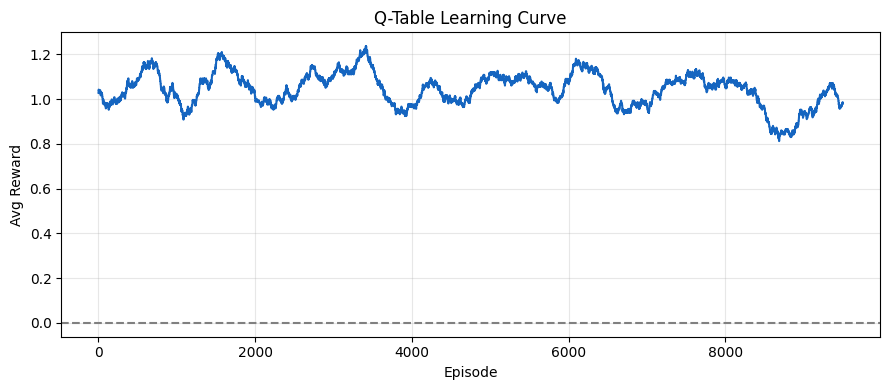

In [4]:
import numpy as np
import matplotlib.pyplot as plt
window = 500
smoothed = np.convolve(rewards, np.ones(window)/window, mode='valid')
plt.figure(figsize=(9,4))
plt.plot(smoothed, color='#1565C0')
plt.axhline(0, color='gray', linestyle='--')
plt.xlabel('Episode'); plt.ylabel('Avg Reward')
plt.title('Q-Table Learning Curve'); plt.grid(alpha=0.3)
plt.tight_layout(); plt.show()

## Stage 2 — Deep RL with PPO

The 2D court has ~240k states — too many for a table. We use a neural network.

In [5]:
from envs.basketball_2d_env import Basketball2DEnv
env2d = Basketball2DEnv(mode='static')
obs, _ = env2d.reset(seed=42)
print('Obs shape:', obs.shape)
print(f'Agent({obs[0]:.0f},{obs[1]:.0f}) | Defender({obs[2]:.0f},{obs[3]:.0f}) | Clock {obs[4]:.0f}')
env2d.close()

Obs shape: (6,)
Agent(0,1) | Defender(0,0) | Clock 1


In [6]:
from training.train_ppo import train as train_ppo
from utils.config import PPOConfig
ppo_config = PPOConfig(total_timesteps=100_000, verbose=1)
model = train_ppo(mode='static', ppo_config=ppo_config, save_dir='../models')

2026-06-02 12:50:20 | INFO     | train_ppo | Running environment sanity check...
2026-06-02 12:50:20 | INFO     | train_ppo | Environment check passed ✓
Using cpu device
Wrapping the env in a DummyVecEnv.
2026-06-02 12:50:21 | INFO     | train_ppo | Training PPO | mode=static | timesteps=100000 | lr=0.0003 | n_steps=2048 | device=cpu
Logging to results/tensorboard/PPO_12


Output()

---------------------------------
| rollout/           |          |
|    ep_len_mean     | 4.81     |
|    ep_rew_mean     | 0.355    |
| time/              |          |
|    fps             | 3656     |
|    iterations      | 1        |
|    time_elapsed    | 0        |
|    total_timesteps | 2048     |
---------------------------------


------------------------------------------
| rollout/                |              |
|    ep_len_mean          | 4.65         |
|    ep_rew_mean          | 0.025        |
| time/                   |              |
|    fps                  | 2441         |
|    iterations           | 2            |
|    time_elapsed         | 1            |
|    total_timesteps      | 4096         |
| train/                  |              |
|    approx_kl            | 0.0095699895 |
|    clip_fraction        | 0.116        |
|    clip_range           | 0.2          |
|    entropy_loss         | -1.6         |
|    explained_variance   | 0.0029       |
|    learning_rate        | 0.0003       |
|    loss                 | 0.288        |
|    n_updates            | 10           |
|    policy_gradient_loss | -0.00741     |
|    value_loss           | 0.513        |
------------------------------------------


-----------------------------------------
| rollout/                |             |
|    ep_len_mean          | 4.14        |
|    ep_rew_mean          | 0.15        |
| time/                   |             |
|    fps                  | 2169        |
|    iterations           | 3           |
|    time_elapsed         | 2           |
|    total_timesteps      | 6144        |
| train/                  |             |
|    approx_kl            | 0.009288277 |
|    clip_fraction        | 0.0639      |
|    clip_range           | 0.2         |
|    entropy_loss         | -1.59       |
|    explained_variance   | -0.00737    |
|    learning_rate        | 0.0003      |
|    loss                 | 0.225       |
|    n_updates            | 20          |
|    policy_gradient_loss | -0.00545    |
|    value_loss           | 0.433       |
-----------------------------------------


...

-----------------------------------------
| rollout/                |             |
|    ep_len_mean          | 9.11        |
|    ep_rew_mean          | 3           |
| time/                   |             |
|    fps                  | 2083        |
|    iterations           | 47          |
|    time_elapsed         | 46          |
|    total_timesteps      | 96256       |
| train/                  |             |
|    approx_kl            | 0.005748891 |
|    clip_fraction        | 0.0604      |
|    clip_range           | 0.2         |
|    entropy_loss         | -0.272      |
|    explained_variance   | 0.962       |
|    learning_rate        | 0.0003      |
|    loss                 | -0.00614    |
|    n_updates            | 460         |
|    policy_gradient_loss | -0.00113    |
|    value_loss           | 0.000257    |
-----------------------------------------


------------------------------------------
| rollout/                |              |
|    ep_len_mean          | 9.16         |
|    ep_rew_mean          | 3            |
| time/                   |              |
|    fps                  | 2085         |
|    iterations           | 48           |
|    time_elapsed         | 47           |
|    total_timesteps      | 98304        |
| train/                  |              |
|    approx_kl            | 0.0027440488 |
|    clip_fraction        | 0.0404       |
|    clip_range           | 0.2          |
|    entropy_loss         | -0.256       |
|    explained_variance   | 0.969        |
|    learning_rate        | 0.0003       |
|    loss                 | -0.00693     |
|    n_updates            | 470          |
|    policy_gradient_loss | -0.000214    |
|    value_loss           | 0.000211     |
------------------------------------------


-----------------------------------------
| eval/                   |             |
|    mean_ep_length       | 8.65        |
|    mean_reward          | 3           |
| time/                   |             |
|    total_timesteps      | 100000      |
| train/                  |             |
|    approx_kl            | 0.007568855 |
|    clip_fraction        | 0.0769      |
|    clip_range           | 0.2         |
|    entropy_loss         | -0.297      |
|    explained_variance   | 0.187       |
|    learning_rate        | 0.0003      |
|    loss                 | -0.028      |
|    n_updates            | 480         |
|    policy_gradient_loss | -0.00125    |
|    value_loss           | 0.0372      |
-----------------------------------------


---------------------------------
| rollout/           |          |
|    ep_len_mean     | 8.92     |
|    ep_rew_mean     | 2.97     |
| time/              |          |
|    fps             | 2084     |
|    iterations      | 49       |
|    time_elapsed    | 48       |
|    total_timesteps | 100352   |
---------------------------------


2026-06-02 12:51:09 | INFO     | train_ppo | Final model saved → ../models/ppo_static.zip
2026-06-02 12:51:09 | INFO     | train_ppo | Best model (during training) → ../models/best_static/best_model.zip


## Stage 3 — Visualise the Agent

In [7]:
from evaluation.visualize import run_simulation
run_simulation(model_path='../models/ppo_static', mode='static', display_inline=True)

2026-06-02 12:51:47 | INFO     | visualize | Simulating episode | mode=static | model=../models/ppo_static | seed=None

Starting Position: Agent at (6, 6) | Defender at (3, 3) | Dist-to-basket: 6.1
  Step  1: Move Up      | Pos (6,5) | Clock 23 | Reward +0.00
  Step  2: Move Up      | Pos (6,4) | Clock 22 | Reward +0.00
  Step  3: Move Up      | Pos (6,3) | Clock 21 | Reward +0.00
  Step  4: Move Up      | Pos (6,2) | Clock 20 | Reward +0.00
  Step  5: Move Up      | Pos (6,1) | Clock 19 | Reward +0.00
  Step  6: Move Left    | Pos (5,1) | Clock 18 | Reward +0.00
  Step  7: Move Up      | Pos (5,0) | Clock 17 | Reward +0.00
  Step  8: SHOOT        | Pos (5,0) | Clock 16 | Reward +3.00  ← SCORED

Episode finished in 8 steps. Total reward: +3.00


3.0

## Stage 4 — Moving Defender + Reward Engineering

The moving defender creates a **local minimum**: the agent learns to shoot immediately
to avoid collision penalties, even though driving inside scores more reliably.

Fix: add progress reward (+0.1 for moving closer) and a miss penalty (-0.2).

In [8]:
ppo_eng = PPOConfig(total_timesteps=150_000, verbose=0)
train_ppo(mode='engineered', ppo_config=ppo_eng, save_dir='../models')
print('Engineered agent trained!')

2026-06-02 12:51:48 | INFO     | train_ppo | Running environment sanity check...
2026-06-02 12:51:48 | INFO     | train_ppo | Environment check passed ✓
2026-06-02 12:51:48 | INFO     | train_ppo | Training PPO | mode=engineered | timesteps=150000 | lr=0.0003 | n_steps=2048 | device=cpu


Output()

2026-06-02 12:53:02 | INFO     | train_ppo | Final model saved → ../models/ppo_engineered.zip
2026-06-02 12:53:02 | INFO     | train_ppo | Best model (during training) → ../models/best_engineered/best_model.zip
Engineered agent trained!


In [9]:
from evaluation.evaluate import evaluate_ppo, print_metrics
m1 = evaluate_ppo('../models/ppo_static',     mode='static',     n_episodes=200)
m2 = evaluate_ppo('../models/ppo_engineered', mode='engineered', n_episodes=200)
print_metrics(m1, 'Static Mode')
print_metrics(m2, 'Engineered Mode')


  Static Mode
  Episodes evaluated : 200
  Mean reward        : +3.0000 ± 0.0000
  Median reward      : +3.0000
  Min / Max reward   : +3.0000 / +3.0000
  Shot success rate  : 100.0%
  Shot clock viol.   : 0.0%
  Collision rate     : 0.0%
  Avg steps/episode  : 9.0

  Outcome breakdown:
    scored                      : 200 (100.0%)


  Engineered Mode
  Episodes evaluated : 200
  Mean reward        : +0.2617 ± 1.1358
  Median reward      : -0.3000
  Min / Max reward   : -0.7000 / +3.7847
  Shot success rate  : 11.0%
  Shot clock viol.   : 0.0%
  Collision rate     : 0.0%
  Avg steps/episode  : 1.9

  Outcome breakdown:
    scored                      : 22 (11.0%)
    missed                      : 169 (84.5%)
    blocked                     : 9 (4.5%)



## Summary

| Stage | Technique | Key Concept |
|-------|-----------|-------------|
| 1 | Q-Table | Bellman equation, tabular RL |
| 2 | PPO static | Neural policy, Gymnasium API |
| 3 | PPO render | Visual evaluation |
| 4 | PPO + shaping | Reward engineering, local minima |

